In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import seaborn as sns
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge, ElasticNet
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")

In [2]:
import os
import pandas as pd

DATA_DIR = r"C:\Users\ASUS\Desktop\Nest_Internship"

train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

In [3]:
print("Train shape:", train.shape)
print("Test shape :", test.shape)
display(train.head(3))

Train shape: (100000, 12)
Test shape : (50000, 11)


,id,company,department,age,age_when_joined,years_in_the_company,salary,annual_bonus,prior_years_experience,full_time,part_time,contractor
0,1,Cheerper,Support,40,36,4,69420.46872,22586.99591,2,0.000000,0.893809,0.328591
1,2,Cheerper,BigData,40,34,6,88407.04974,18676.07837,3,0.205947,0.756632,0.036870
2,3,Pear,Sales,41,39,2,97831.84885,19287.87365,2,0.942309,0.000000,0.514457


In [4]:
print("\nColumn types:")
print(train.dtypes)


Column types:
id                          int64
company                       str
department                    str
age                         int64
age_when_joined             int64
years_in_the_company        int64
salary                    float64
annual_bonus              float64
prior_years_experience      int64
full_time                 float64
part_time                 float64
contractor                float64
dtype: object


In [5]:
na_train = train.isna().sum().sort_values(ascending=False).head(15)
na_test  = test.isna().sum().sort_values(ascending=False).head(15)
print("\nMissing values (train):\n", na_train)
print("\nMissing values (test):\n", na_test)


Missing values (train):
 id                        0
company                   0
department                0
age                       0
age_when_joined           0
years_in_the_company      0
salary                    0
annual_bonus              0
prior_years_experience    0
full_time                 0
part_time                 0
contractor                0
dtype: int64

Missing values (test):
 id                        0
company                   0
department                0
age                       0
age_when_joined           0
years_in_the_company      0
annual_bonus              0
prior_years_experience    0
full_time                 0
part_time                 0
contractor                0
dtype: int64


In [6]:
train.describe()

,id,age,age_when_joined,years_in_the_company,salary,annual_bonus,prior_years_experience,full_time,part_time,contractor
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,38.195870,33.537060,4.667780,87389.018245,18582.064815,2.505540,0.383531,0.383279,0.382016
std,28867.657797,6.013073,7.719078,2.531773,28478.542805,4373.431365,1.207222,0.340638,0.339783,0.339621
min,1.000000,30.000000,22.000000,1.000000,40000.000000,9000.000000,1.000000,0.000000,0.000000,0.000000
25%,25000.750000,33.000000,27.000000,3.000000,66027.961360,15448.885482,1.000000,0.016171,0.015702,0.013575
50%,50000.500000,38.000000,33.000000,5.000000,86554.204990,18821.651785,2.000000,0.333278,0.334739,0.331437
75%,75000.250000,43.000000,39.000000,7.000000,107269.920325,22168.522630,3.000000,0.653879,0.650733,0.649338
max,100000.000000,49.000000,48.000000,9.000000,153000.000000,24792.910000,5.000000,1.000000,1.000000,1.000000



Target describe():
count    100000.000000
mean      87389.018245
std       28478.542805
min       40000.000000
25%       66027.961360
50%       86554.204990
75%      107269.920325
max      153000.000000
Name: salary, dtype: float64


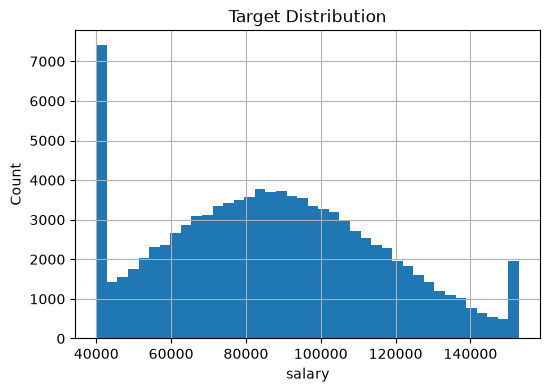

In [7]:
target_col = "salary"  # adjust if different
if target_col in train.columns:
    print("\nTarget describe():")
    print(train[target_col].describe())

 # Histogram of target
    import matplotlib.pyplot as plt
    plt.figure(figsize=(6,4))
    train[target_col].hist(bins=40)
    plt.xlabel(target_col)
    plt.ylabel("Count")
    plt.title("Target Distribution")
    plt.show()
else:
    print("⚠️ Target column not found – please check column names!")

In [8]:
target_col = "salary"
id_col     = "id"

# features = all columns except id + target
features = [c for c in train.columns if c not in [id_col, target_col]]
cat_cols = [c for c in features if train[c].dtype == "object"]
num_cols = [c for c in features if c not in cat_cols]

print(f"Features: {len(features)} | Numeric: {len(num_cols)} | Categorical: {len(cat_cols)}")

Features: 10 | Numeric: 10 | Categorical: 0


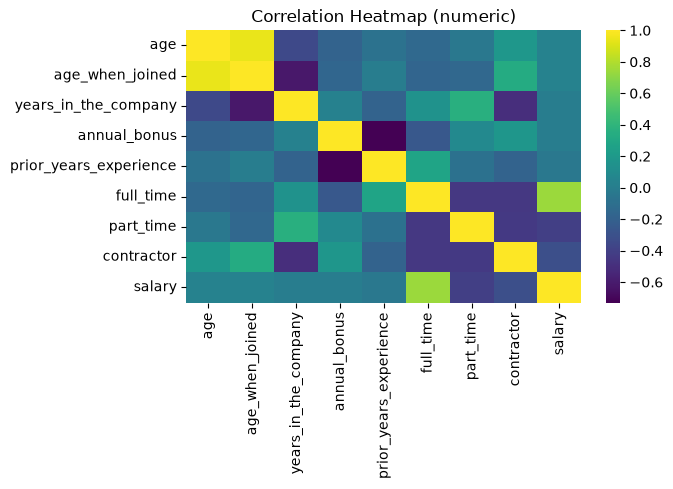

In [9]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
try:
    import seaborn as sns
    USE_SNS = True
except Exception:
    USE_SNS = False

num_for_corr = train[[*num_cols, target_col]].copy()
corr = num_for_corr.corr(numeric_only=True)

plt.figure(figsize=(7,5))
if USE_SNS:
    sns.heatmap(corr, annot=False, cmap="viridis")
else:
    # simple matplotlib fallback
    plt.imshow(corr, cmap="viridis"); plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Heatmap (numeric)")
plt.tight_layout()
plt.show()

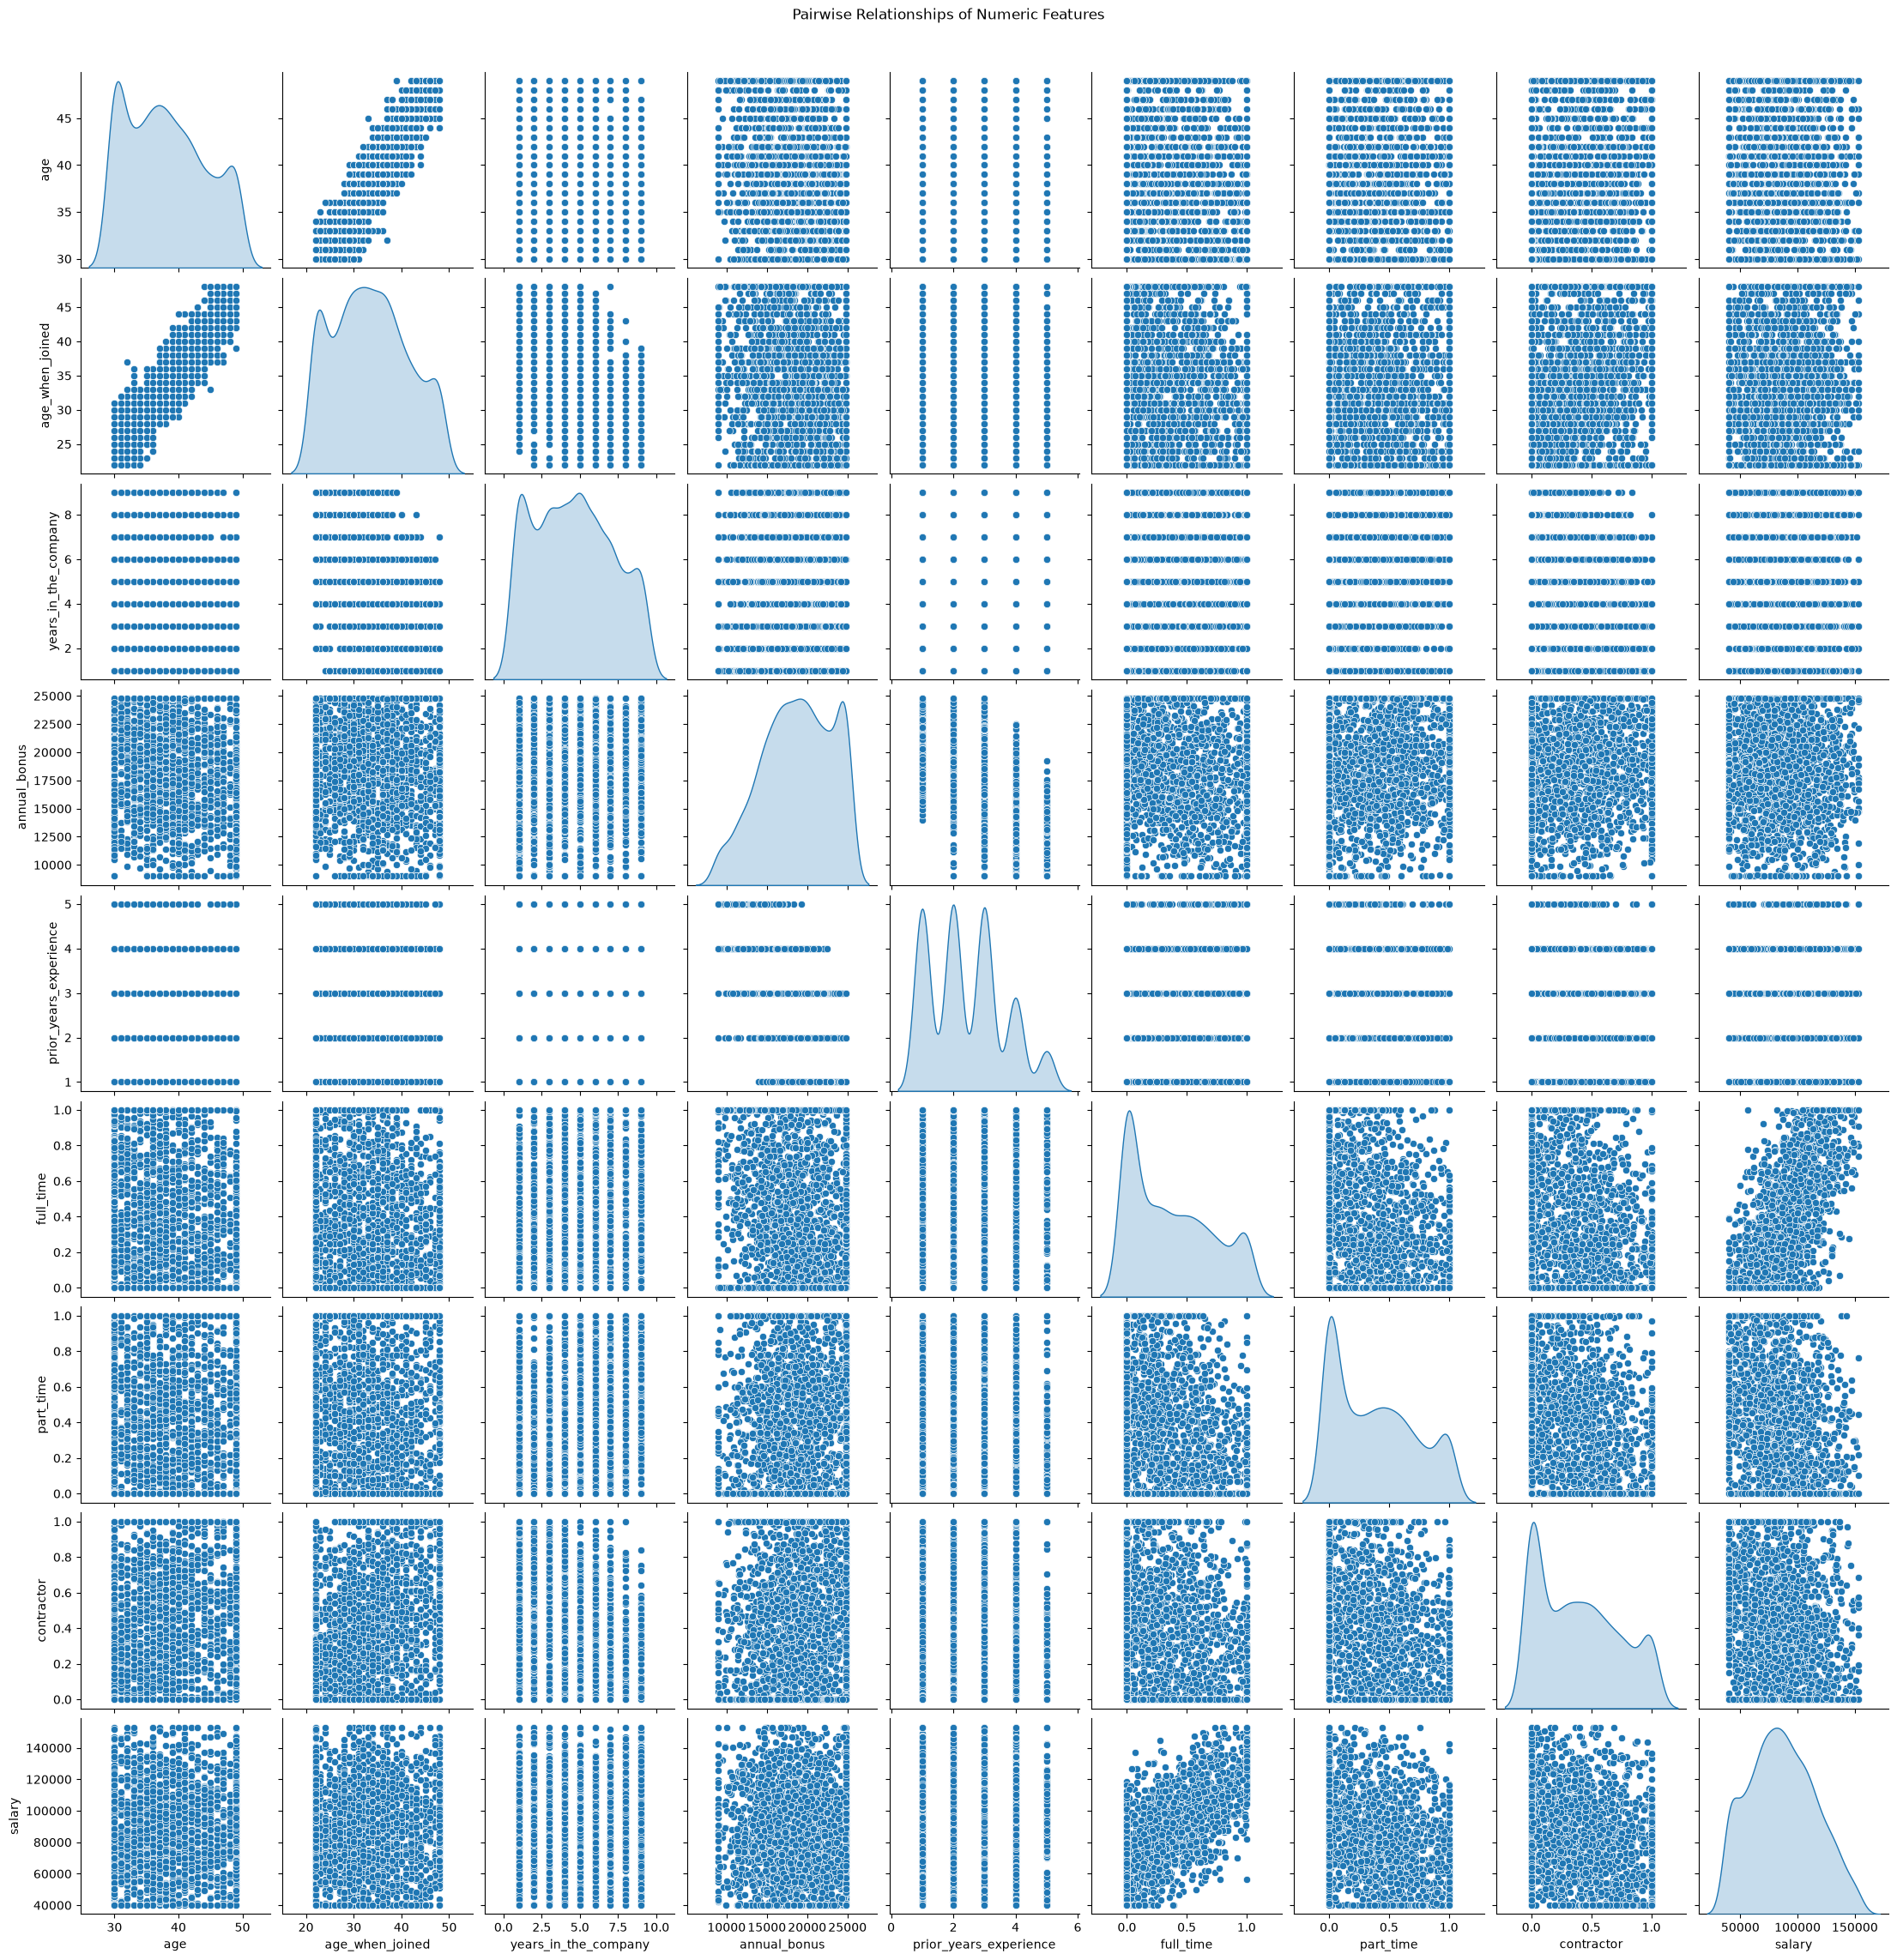

In [10]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")


numeric_features = num_cols  # from earlier split
sampled_train = train.sample(2000, random_state=42)  # sample to keep plot fast
sns.pairplot(sampled_train[numeric_features + [target_col]], diag_kind="kde")
plt.suptitle("Pairwise Relationships of Numeric Features", y=1.02)
plt.show()

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=train, x=col, y=target_col)
    plt.title(f"Salary Distribution by {col}")
    plt.xticks(rotation=45)
    plt.show()

In [11]:
# Age difference
train["age_diff"] = train["age"] - train["age_when_joined"]
test["age_diff"]  = test["age"] - test["age_when_joined"]

# Bonus per year
train["bonus_per_year"] = train["annual_bonus"] / (train["years_in_the_company"] + 1)
test["bonus_per_year"]  = test["annual_bonus"] / (test["years_in_the_company"] + 1)

# Total experience
train["total_experience"] = train["prior_years_experience"] + train["years_in_the_company"]
test["total_experience"]  = test["prior_years_experience"] + test["years_in_the_company"]

# Experience ratio
train["experience_ratio"] = train["prior_years_experience"] / (train["years_in_the_company"] + 1)
test["experience_ratio"]  = test["prior_years_experience"] / (test["years_in_the_company"] + 1)

# Company–Department combo
train["company_department"] = train["company"] + "_" + train["department"]
test["company_department"]  = test["company"] + "_" + test["department"]

# Employment type (argmax across one-hot style cols)
train["employment_type"] = train[["full_time","part_time","contractor"]].idxmax(axis=1)
test["employment_type"]  = test[["full_time","part_time","contractor"]].idxmax(axis=1)

In [35]:
print(X_train.dtypes)
print(X_train.select_dtypes(include=["number"]).columns.tolist())
print(X_train.select_dtypes(exclude=["number"]).columns.tolist())

company                       str
department                    str
age                         int64
age_when_joined             int64
years_in_the_company        int64
annual_bonus              float64
prior_years_experience      int64
full_time                 float64
part_time                 float64
contractor                float64
age_diff                    int64
bonus_per_year            float64
total_experience            int64
experience_ratio          float64
company_department            str
employment_type               str
dtype: object
['age', 'age_when_joined', 'years_in_the_company', 'annual_bonus', 'prior_years_experience', 'full_time', 'part_time', 'contractor', 'age_diff', 'bonus_per_year', 'total_experience', 'experience_ratio']
['company', 'department', 'company_department', 'employment_type']


In [36]:
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

cat_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric:", num_cols)
print("Categorical:", cat_cols)

Numeric: ['age', 'age_when_joined', 'years_in_the_company', 'annual_bonus', 'prior_years_experience', 'full_time', 'part_time', 'contractor', 'age_diff', 'bonus_per_year', 'total_experience', 'experience_ratio']
Categorical: ['company', 'department', 'company_department', 'employment_type']


In [49]:
num_cols = [
    'age',
    'age_when_joined',
    'years_in_the_company',
    'annual_bonus',
    'prior_years_experience',
    'full_time',
    'part_time',
    'contractor',
    'age_diff',
    'bonus_per_year',
    'total_experience',
    'experience_ratio'
]

cat_cols = [
    'company',
    'department',
    'company_department',
    'employment_type'
]

In [61]:
Xtr_enc = prep.fit_transform(X_train)
Xva_enc = prep.transform(X_val)

print(Xtr_enc.shape)
print(Xva_enc.shape)

(80000, 40)
(20000, 40)


In [62]:
print(num_cols)
print(cat_cols)

['age', 'age_when_joined', 'years_in_the_company', 'annual_bonus', 'prior_years_experience', 'full_time', 'part_time', 'contractor', 'age_diff', 'bonus_per_year', 'total_experience', 'experience_ratio']
['company', 'department', 'company_department', 'employment_type']


In [64]:
print(best_model)

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03, n_estimators=3000,
              objective='mae', random_state=42, subsample=0.8)


In [65]:
import joblib

joblib.dump(best_model, "LightGBM_model.pkl")
joblib.dump(prep, "preprocessor.pkl")

['preprocessor.pkl']

In [68]:
import joblib

model = joblib.load("LightGBM_model.pkl")
prep = joblib.load("preprocessor.pkl")

In [69]:
for c in num_cols:
    if not pd.api.types.is_numeric_dtype(X_train[c]):
        print("Non-numeric in num_cols:", c, X_train[c].dtype)

In [70]:
print("num_cols:")
print(num_cols)

print("\ncat_cols:")
print(cat_cols)

num_cols:
['age', 'age_when_joined', 'years_in_the_company', 'annual_bonus', 'prior_years_experience', 'full_time', 'part_time', 'contractor', 'age_diff', 'bonus_per_year', 'total_experience', 'experience_ratio']

cat_cols:
['company', 'department', 'company_department', 'employment_type']


In [71]:
Xtr_enc = prep.fit_transform(X_train)
Xva_enc = prep.transform(X_val)

In [72]:
print(Xtr_enc.shape)
print(Xva_enc.shape)

(80000, 40)
(20000, 40)


In [73]:
model.fit(Xtr_enc, y_train)
preds = model.predict(Xva_enc)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002678 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1462
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 38
[LightGBM] [Info] Start training from score 86611.070312


C:\Users\ASUS\Desktop\Nest_Internship\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [74]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [75]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [76]:
model.fit(Xtr_enc, y_train)

preds = model.predict(Xva_enc)

from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_val, preds)
print("MAE:", mae)

MAE: 12203.19479851547


In [77]:


print(Xtr_enc.shape)
print(y_train.shape)

(80000, 40)
(80000,)


In [110]:
# =========================================
# 🚀 compact encode + 5 models (fixed)
# =========================================
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, ElasticNet
import matplotlib.pyplot as plt

# Optional boosters (skip gracefully if not installed)
XGB_OK = LGB_OK = True
try:
    from xgboost import XGBRegressor
except Exception:
    XGB_OK = False
try:
    import lightgbm as lgb
    from lightgbm import LGBMRegressor
except Exception:
    LGB_OK = False

# --- columns ---
target_col, id_col = "salary", "id"
features = [c for c in train.columns if c not in [target_col, id_col]]
num_cols = train[features].select_dtypes(include=["number"]).columns.tolist()

cat_cols = train[features].select_dtypes(exclude=["number"]).columns.tolist()

# --- robust: replace inf ---
train = train.replace([np.inf, -np.inf], np.nan)
test  = test.replace([np.inf, -np.inf], np.nan)

X = train[features]
y = train[target_col].values
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# --- single encoder (fast): numeric impute + ordinal encode categoricals ---
prep = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols),
    ],
    remainder="drop"
)

# fit-transform once (speed!)
Xtr_enc = prep.fit_transform(X_train)
Xva_enc = prep.transform(X_val)
Xte_enc = prep.transform(test[features])

# --- models (lean configs) ---
models = {
    "RandomForest": RandomForestRegressor(n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=42),
    "Ridge":        Ridge(alpha=1.0, random_state=42),
    "ElasticNet":   ElasticNet(alpha=0.08, l1_ratio=0.5, max_iter=4000, random_state=42),
}
if XGB_OK:
    models["XGBoost"] = XGBRegressor(
        n_estimators=1200,
        learning_rate=0.05,
        max_depth=7,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
        early_stopping_rounds=150   # ✅ moved to constructor (no warning)
    )
if LGB_OK:
    models["LightGBM"] = LGBMRegressor(
        n_estimators=3000, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8,
        objective="mae", random_state=42
    )

# --- linear models benefit from scaling ---
scaler = StandardScaler()
Xtr_scaled = scaler.fit_transform(Xtr_enc)
Xva_scaled = scaler.transform(Xva_enc)
Xte_scaled = scaler.transform(Xte_enc)

rows = []
pred_val_cache = {}

for name, model in models.items():
    if name in ["Ridge", "ElasticNet"]:
        model.fit(Xtr_scaled, y_train)
        pred = model.predict(Xva_scaled)
    elif name == "XGBoost" and XGB_OK:
        # ✅ early_stopping set in constructor; no kwarg in fit()
        model.fit(Xtr_enc, y_train, eval_set=[(Xva_enc, y_val)], verbose=False)
        pred = model.predict(Xva_enc)
    elif name == "LightGBM" and LGB_OK:
        model.fit(Xtr_enc, y_train,
                  eval_set=[(Xva_enc, y_val)],
                  eval_metric="mae",
                  callbacks=[lgb.early_stopping(150, verbose=False)])
        pred = model.predict(Xva_enc)
    else:
        model.fit(Xtr_enc, y_train)
        pred = model.predict(Xva_enc)

    rmse = np.sqrt(mean_squared_error(y_val, pred))
    mae  = mean_absolute_error(y_val, pred)
    rows.append({"Model": name, "Val RMSE": rmse, "Val MAE": mae})
    pred_val_cache[name] = pred

results_df = pd.DataFrame(rows).sort_values("Val MAE").reset_index(drop=True)

best_name = results_df.loc[0, "Model"]
print("✅ Best by MAE:", best_name)
best_model = models[best_name]


#  fit best on full train 
# re-encode full train once
Xfull_enc = prep.fit_transform(X)
Xtest_enc = prep.transform(test[features])

if best_name in ["Ridge", "ElasticNet"]:
    scaler_full = StandardScaler().fit(Xfull_enc)
    Xfull_enc = scaler_full.transform(Xfull_enc)
    Xtest_enc = scaler_full.transform(Xtest_enc)

# final fit
if best_name == "XGBoost" and XGB_OK:
    best_model.fit(Xfull_enc, y, verbose=False)
elif best_name == "LightGBM" and LGB_OK:
    best_model.fit(Xfull_enc, y)
else:
    best_model.fit(Xfull_enc, y)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008192 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1437
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 16
[LightGBM] [Info] Start training from score 86611.070312


C:\Users\ASUS\Desktop\Nest_Internship\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


✅ Best by MAE: LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010779 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1437
[LightGBM] [Info] Number of data points in the train set: 100000, number of used features: 16
[LightGBM] [Info] Start training from score 86554.203125


In [79]:
for col in X_train.columns:
    if X_train[col].astype(str).str.contains("Glasses", na=False).any():
        print("Found in:", col)

Found in: company
Found in: company_department


In [80]:
print(X_train.columns.tolist())

['company', 'department', 'age', 'age_when_joined', 'years_in_the_company', 'annual_bonus', 'prior_years_experience', 'full_time', 'part_time', 'contractor', 'age_diff', 'bonus_per_year', 'total_experience', 'experience_ratio', 'company_department', 'employment_type']


In [81]:
print(X_train.head())

        company     department  age  age_when_joined  years_in_the_company  \
75220   Glasses             AI   37               35                     2   
48955      Pear         Design   47               46                     2   
44966   Glasses  Search Engine   37               32                     6   
13568  Cheerper        BigData   38               32                     6   
92727   Glasses        BigData   41               37                     4   

       annual_bonus  prior_years_experience  full_time  part_time  contractor  \
75220   17571.63041                       4   0.517411   0.097896    0.384595   
48955   11651.40271                       5   0.756924   0.000000    0.518063   
44966   17187.91157                       3   0.740097   0.296316    0.000000   
13568   20970.19891                       1   0.000000   0.927473    0.160246   
92727   15805.44204                       3   0.196771   0.766961    0.035848   

       age_diff  bonus_per_year  total_exper

In [82]:
print(X_train.shape)
print(X_train.columns.tolist())
print(X_train.head(3))

(80000, 16)
['company', 'department', 'age', 'age_when_joined', 'years_in_the_company', 'annual_bonus', 'prior_years_experience', 'full_time', 'part_time', 'contractor', 'age_diff', 'bonus_per_year', 'total_experience', 'experience_ratio', 'company_department', 'employment_type']
       company     department  age  age_when_joined  years_in_the_company  \
75220  Glasses             AI   37               35                     2   
48955     Pear         Design   47               46                     2   
44966  Glasses  Search Engine   37               32                     6   

       annual_bonus  prior_years_experience  full_time  part_time  contractor  \
75220   17571.63041                       4   0.517411   0.097896    0.384595   
48955   11651.40271                       5   0.756924   0.000000    0.518063   
44966   17187.91157                       3   0.740097   0.296316    0.000000   

       age_diff  bonus_per_year  total_experience  experience_ratio  \
75220         

In [83]:
display(results_df)
print("✅ Best by MAE:", best_name)

,Model,Val RMSE,Val MAE
0,LightGBM,14678.295415,11647.902563
1,XGBoost,14655.047413,11702.836666
2,RandomForest,15227.467387,12158.573029
3,Ridge,15897.449965,12778.576733
4,ElasticNet,15994.771710,12888.364206


✅ Best by MAE: LightGBM


In [84]:
sample_submission = pd.read_csv(r"C:\Users\ASUS\Desktop\Nest_Internship\sample-submission.csv")

In [85]:
test_pred = best_model.predict(Xtest_enc)

sub = sample_submission.copy()

target_cols = [c for c in sub.columns if c.lower() not in ["id", "employee_id", "emp_id"]]

sub[target_cols[0]] = test_pred

sub.to_csv("submission.csv", index=False)

print(sub.head())

C:\Users\ASUS\Desktop\Nest_Internship\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


   id         salary
0   1   51318.910867
1   2   97039.298100
2   3   59211.898085
3   4  122860.125486
4   5   61793.447901


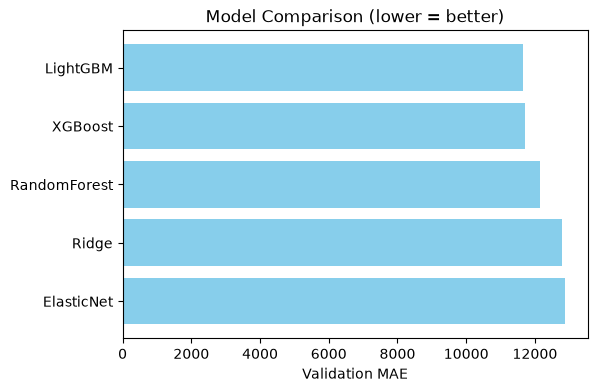

In [86]:
plt.figure(figsize=(6,4))
plt.barh(results_df["Model"], results_df["Val MAE"], color="skyblue")
plt.xlabel("Validation MAE")
plt.title("Model Comparison (lower = better)")
plt.gca().invert_yaxis()
plt.show()

C:\Users\ASUS\Desktop\Nest_Internship\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


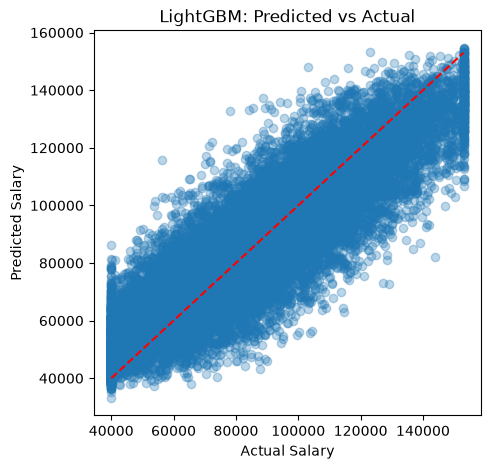

In [87]:
best_pred = best_model.predict(Xva_enc if best_name not in ["Ridge","ElasticNet"] else Xva_scaled)
plt.figure(figsize=(5,5))
plt.scatter(y_val, best_pred, alpha=0.3)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title(f"{best_name}: Predicted vs Actual")
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "r--")
plt.show()

In [88]:
print(type(Xtest_enc))

<class 'numpy.ndarray'>


In [89]:
print(X_train.columns)

Index(['company', 'department', 'age', 'age_when_joined',
       'years_in_the_company', 'annual_bonus', 'prior_years_experience',
       'full_time', 'part_time', 'contractor', 'age_diff', 'bonus_per_year',
       'total_experience', 'experience_ratio', 'company_department',
       'employment_type'],
      dtype='str')


In [90]:
Xtest_enc = pd.DataFrame(
    Xtest_enc,
    columns=X_train.columns
)

In [91]:
test_pred = best_model.predict(Xtest_enc)

In [92]:
print(type(X_train))
print(type(Xtest_enc))

print(X_train.shape)
print(Xtest_enc.shape)

<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>
(80000, 16)
(50000, 16)


In [93]:
import joblib

joblib.dump(best_model, f"{best_name}_model.pkl")
print(f"✅ Saved {best_name}_model.pkl")

✅ Saved LightGBM_model.pkl


In [95]:
print(X.columns.tolist())
print(X.dtypes)

['company', 'department', 'age', 'age_when_joined', 'years_in_the_company', 'annual_bonus', 'prior_years_experience', 'full_time', 'part_time', 'contractor', 'age_diff', 'bonus_per_year', 'total_experience', 'experience_ratio', 'company_department', 'employment_type']
company                       str
department                    str
age                         int64
age_when_joined             int64
years_in_the_company        int64
annual_bonus              float64
prior_years_experience      int64
full_time                 float64
part_time                 float64
contractor                float64
age_diff                    int64
bonus_per_year            float64
total_experience            int64
experience_ratio          float64
company_department            str
employment_type               str
dtype: object


In [112]:
import joblib

joblib.dump(prep, "preprocessor.pkl")
joblib.dump(best_model, "LightGBM_model.pkl")

print("Files saved")

Files saved


In [113]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\ASUS\Desktop\Nest_Internship\Employee_Salary_Prediction
['.ipynb_checkpoints', 'app.py', 'Employee_Salary_Prediction.ipynb', 'LightGBM_model.pkl', 'model', 'preprocessor.pkl', 'requirements.txt', 'submission.csv', 'venv']


In [114]:
print("Original features:", len(features))

sample = X.iloc[:1]
encoded = prep.transform(sample)

print("Encoded shape:", encoded.shape)

Original features: 16
Encoded shape: (1, 16)


In [115]:
import joblib

joblib.dump(prep, "preprocessor.pkl")
joblib.dump(best_model, "LightGBM_model.pkl")

['LightGBM_model.pkl']

In [116]:
import joblib

joblib.dump(prep, "preprocessor.pkl")
print("preprocessor saved")

preprocessor saved


In [117]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'app.py', 'Employee_Salary_Prediction.ipynb', 'LightGBM_model.pkl', 'model', 'preprocessor.pkl', 'requirements.txt', 'submission.csv', 'venv']
